# Criterion 1 — Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv("../data/Filtered_Sheffield_Traffic_Data.csv",
low_memory=False)

df = df_raw.copy()
print(f"Raw rows: {len(df)}")

Raw rows: 7933


## Exploratory Data Analysis

In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df.describe(include="all"))

# check the distribution of collision severity
print(df["collision_severity"].value_counts())

(7933, 44)
collision_index                                         str
collision_year                                        int64
collision_ref_no                                        str
location_easting_osgr                               float64
location_northing_osgr                              float64
longitude                                           float64
latitude                                            float64
police_force                                          int64
collision_severity                                    int64
number_of_vehicles                                    int64
number_of_casualties                                  int64
date                                                    str
day_of_week                                           int64
time                                                    str
local_authority_district                              int64
local_authority_ons_district                            str
local_authority_highway      

## Handle Sentinel / Missing Values

STATS19 encodes missing data as -1. Heres how I will handle them.

1. Categorical columns: replace -1 with NaN so the imputer treats them as missing.
2. Purely numeric columns: -1 is physically impossible (you cannot have -1 vehicles), so we also replace with `NaN` before imputing.

In [3]:
# sentinel columns — replace -1 with NaN
sentinel_cols = ["junction_control", "junction_detail", "pedestrian_crossing_human_control",
                 "pedestrian_crossing_physical_facilities", "special_conditions_at_site",
                 "carriageway_hazards", "did_police_officer_attend_scene_of_accident"]
for col in sentinel_cols:
    if col in df.columns:
        df[col] = df[col].replace(-1, np.nan)

# clean -1 from numeric columns where -1 is impossible
numeric_sentinel_cols = ["speed_limit", "number_of_vehicles", "number_of_casualties"]
for col in numeric_sentinel_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"Replacing {neg_count} negative values in '{col}' with NaN")
            df[col] = df[col].where(df[col] >= 0, np.nan)

# convert time to hour
df["hour"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.hour

## Impute the Missing Values

In [4]:
from sklearn.impute import SimpleImputer

# impute numeric columns with median as the numeric columns can become more skewed with outliers which would be effected more by using the mean, categorical with mode
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

imp_median = SimpleImputer(strategy="median")
df[numeric_cols] = imp_median.fit_transform(df[numeric_cols])

imp_mode = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = imp_mode.fit_transform(df[categorical_cols])

C:\Users\Noel\AppData\Local\Temp\ipykernel_17488\2561587273.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


## Outlier Detection and Scaling

We use IQR clipping to cap extreme outliers, then apply three scalers so downstream models can choose:

- RobustScaler — uses median and IQR; best when the data is still skewed.
- StandardScaler — zero mean, unit variance; assumes approximately normal distribution.
- MinMaxScaler — squashes values to [0, 1]; useful for distance-based models like KNN.

In [5]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

cols_to_scale = ["number_of_vehicles", "number_of_casualties", "speed_limit"]

# IQR clipping to reduce the huge influence that exteme outliers would have on scaling.
for col in cols_to_scale:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

# chose robust scaler as it less effected by outliers compared to standard and minmax scalers.
rs = RobustScaler()
df[cols_to_scale] = rs.fit_transform(df[cols_to_scale])

# stored for reference / comparison
ss = StandardScaler()
df_standard = df.copy()
df_standard[cols_to_scale] = ss.fit_transform(df[cols_to_scale])

# stored for reference / comparison
mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[cols_to_scale] = mm.fit_transform(df[cols_to_scale])

print("RobustScaler sample:")
print(df[cols_to_scale].describe().round(3))

print("\nStandardScaler sample:")
print(df_standard[cols_to_scale].describe().round(3))

print("\nMinMaxScaler sample (range should be 0–1):")
print(df_minmax[cols_to_scale].describe().round(3))

RobustScaler sample:
       number_of_vehicles  number_of_casualties  speed_limit
count            7933.000               7933.00     7933.000
mean               -0.316                  0.30        2.756
std                 0.631                  0.74        8.009
min                -1.000                  0.00      -10.000
25%                -1.000                  0.00        0.000
50%                 0.000                  0.00        0.000
75%                 0.000                  0.00        0.000
max                 1.500                 10.00       40.000

StandardScaler sample:
       number_of_vehicles  number_of_casualties  speed_limit
count            7933.000              7933.000     7933.000
mean               -0.000                -0.000       -0.000
std                 1.000                 1.000        1.000
min                -1.085                -0.405       -1.593
25%                -1.085                -0.405       -0.344
50%                 0.501               

## Post-Cleaning Data Quality Summary

After all cleaning steps I verify the dataset is in a healthy state before saving.

In [6]:
print("=== Post-Cleaning Summary ===")
print(f"Shape : {df.shape}")
print()

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("Missing values : None — all columns are complete")
else:
    print("Remaining missing values:")
    print(missing)

print()
print("Column dtypes:")
print(df.dtypes)

=== Post-Cleaning Summary ===
Shape : (7933, 45)

Missing values : None — all columns are complete

Column dtypes:
collision_index                                         str
collision_year                                      float64
collision_ref_no                                        str
location_easting_osgr                               float64
location_northing_osgr                              float64
longitude                                           float64
latitude                                            float64
police_force                                        float64
collision_severity                                  float64
number_of_vehicles                                  float64
number_of_casualties                                float64
date                                                    str
day_of_week                                         float64
time                                                    str
local_authority_district                     

## Visual EDA

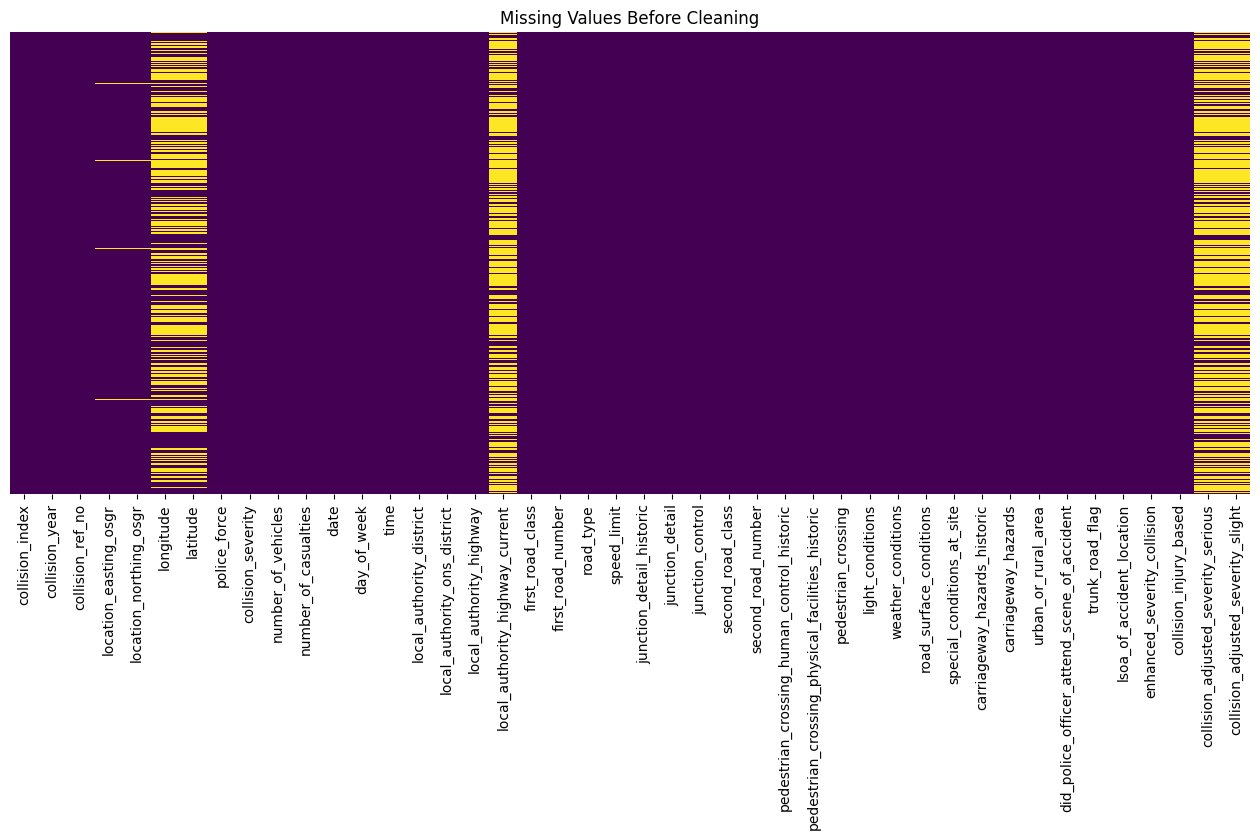

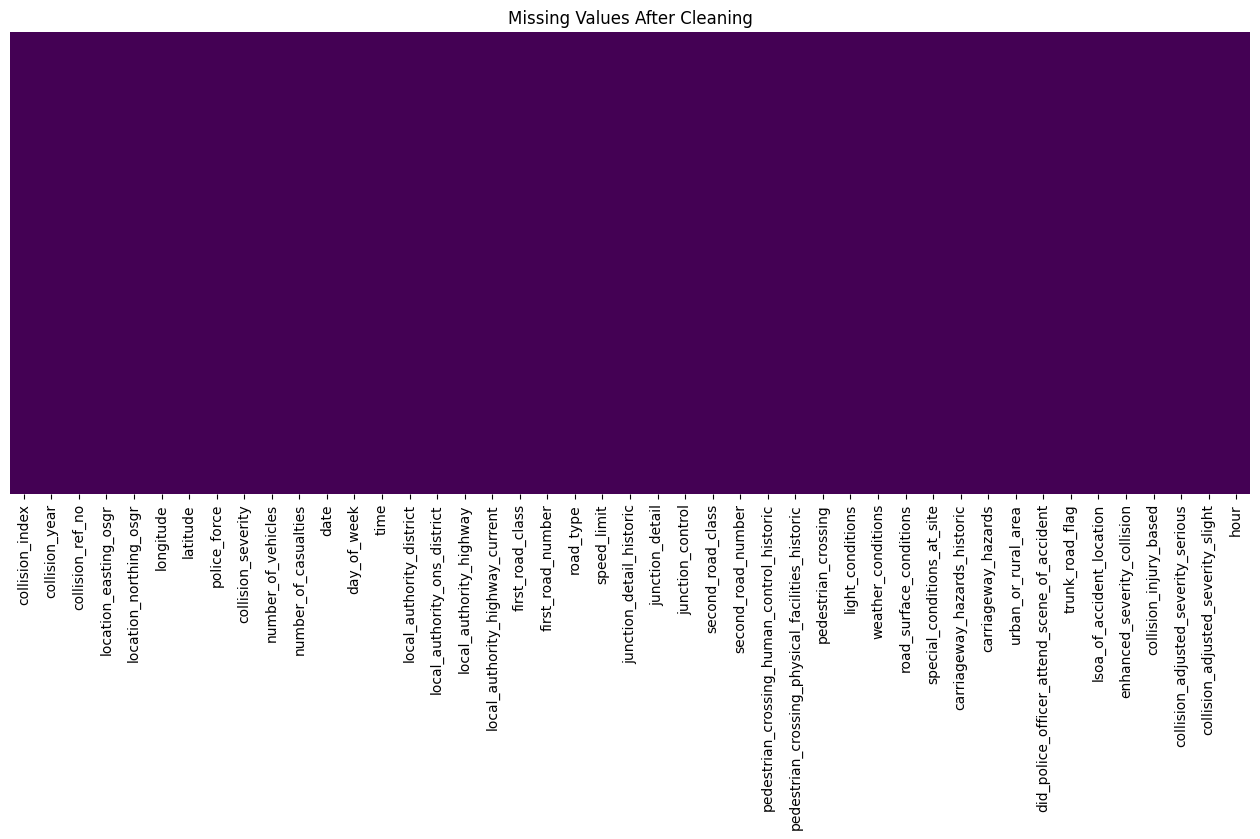

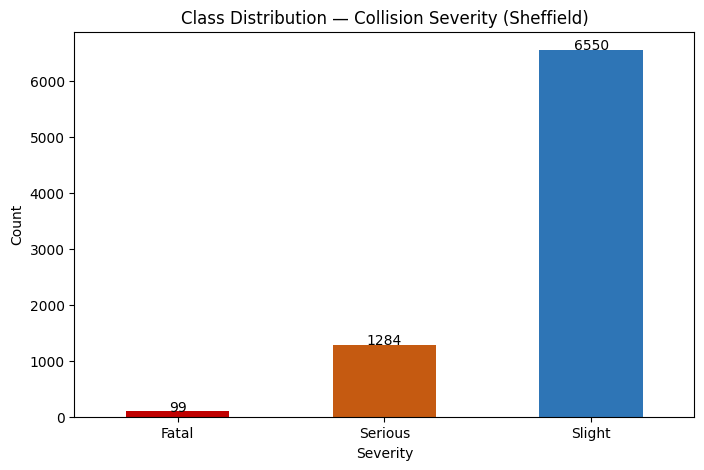

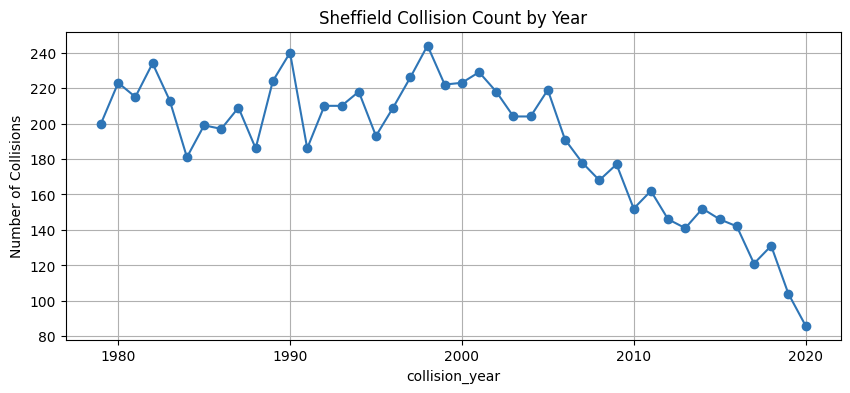

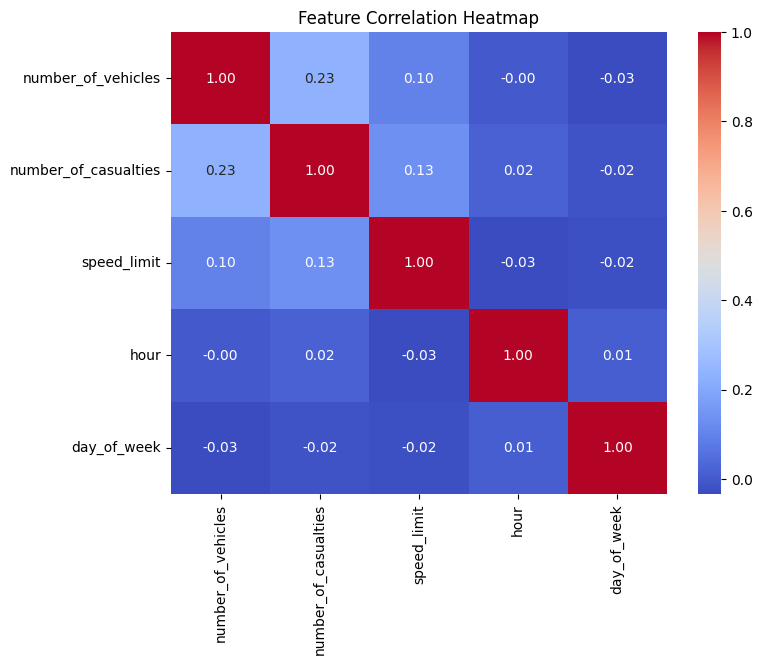

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# missing values before / after
plt.figure(figsize=(16, 6))
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values Before Cleaning")
plt.savefig("../results/C1-missing_before.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values After Cleaning")
plt.savefig("../results/C1-missing_after.png", bbox_inches="tight")
plt.show()

# class distribution of collision severity
plt.figure(figsize=(8, 5))
severity_counts = df["collision_severity"].value_counts().sort_index()
severity_counts.index = severity_counts.index.map({1: "Fatal", 2: "Serious", 3: "Slight"})
severity_counts.plot(kind="bar", color=["#C00000", "#C55A11", "#2E75B6"])
plt.title("Class Distribution — Collision Severity (Sheffield)")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(severity_counts):
    plt.text(i, v + 5, str(v), ha="center", fontsize=10)
plt.savefig("../results/C1-severity_dist.png", bbox_inches="tight")
plt.show()

# yearly trend of collision counts
plt.figure(figsize=(10, 4))
df.groupby("collision_year").size().plot(marker="o", color="#2E75B6")
plt.title("Sheffield Collision Count by Year")
plt.ylabel("Number of Collisions")
plt.grid(True)
plt.savefig("../results/C1-trend_year.png", bbox_inches="tight")
plt.show()

# correlation heatmap of the main numeric features
feat = ["number_of_vehicles", "number_of_casualties", "speed_limit", "hour", "day_of_week"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[feat].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("../results/C1-correlation.png", bbox_inches="tight")
plt.show()

# Exploratory Data Analysis — Sheffield Collisions

## 1. Data Completeness & Cleaning

Before Cleaning: The initial missing values heatmap highlights significant data gaps in latitude and longitude.

After Cleaning: The post-cleaning heatmap shows a completely solid colour block, confirming that the imputation strategy (median for numerics, mode for categoricals) successfully resolved all NaN values.

## 2. Target Variable: Collision Severity

Highly Imbalanced Classes: The bar chart reveals that there is a significant class imbalance, I will have to use a technique like SMOTE to handle this or else the models may end up being too safe and guessing Slight everytime for the severity which would go against the AI Ethics as it'd be much more useful to predict fatal or serious collisions compared to just Slight collisions.

## 3. Temporal Trends (1979–2020)

Historical Fluctuations: From 1979 through the mid-2000s, annual collision counts in Sheffield fluctuated between roughly 180 and 240 incidents per year.

Long-term Decline: Starting around 2008 there is a distinct downward trend, likely reflecting improved road safety legislation, vehicle safety technology, and enforcement.

2020 Drop: The sharp drop at the end is almost certainly an anomaly caused by reduced traffic during COVID-19 lockdowns.

## 4. Feature Correlation (Numeric Variables)

Overall Weak Linear Relationships: The heatmap indicates very weak linear correlations between most numeric features. Time-based features like hour and day_of_week show near-zero correlation with crash metrics.

Notable Interactions: The strongest relationship is a weak positive correlation of 0.23 between number_of_vehicles and number_of_casualties — this makes sense as multiple vehicles generally would have a higher chance for the number of casualties. There is also a minor positive correlation 0.13 between speed_limit and number_of_casualties.

Modelling Takeaway: Because standard linear correlation between features is low, simple linear models may struggle. Tree-based models like Random Forest and XGBoost are likely to be more effective as they can capture non-linear relationships.

In [8]:
# Save the preprocessed data
df.to_csv("../data/Preprocessed_Traffic_Data.csv", index=False)